In [3]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
# ============================================================
# CELL 2: LOAD THE DATASET
# ============================================================

# Name of the CSV file
DATA_FILE = "Building Energy Efficiency.csv"

# Check whether the file exists
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"'{DATA_FILE}' was not found.\n"
        "Please put the CSV file in the same folder as this notebook."
    )

# Read the CSV file
df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print()
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

print()
print("First 5 rows:")
display(df.head())

Dataset loaded successfully.

Number of rows    : 768
Number of columns : 10

First 5 rows:


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.7638,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.9800,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.9800,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.9800,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.9000,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
# ============================================================
# CELL 2: LOAD THE DATASET
# ============================================================

# Name of the CSV file
DATA_FILE = "Building Energy Efficiency.csv"

# Check whether the file exists
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"'{DATA_FILE}' was not found.\n"
        "Please put the CSV file in the same folder as this notebook."
    )

# Read the CSV file
df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print()
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

print()
print("First 5 rows:")
display(df.head())

Dataset loaded successfully.

Number of rows    : 768
Number of columns : 10

First 5 rows:


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.7638,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.9800,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.9800,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.9800,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.9000,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [6]:
# ============================================================
# CELL 4: SELECT INPUT FEATURES AND TARGET VARIABLES
# ============================================================

# ------------------------------------------------------------
# INPUT FEATURES
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    "Relative Compactness",
    "Surface Area",
    "Wall Area",
    "Roof Area",
    "Overall Height",
    "Orientation",
    "Glazing Area",
    "Glazing Area Distribution"
]


# ------------------------------------------------------------
# TARGET VARIABLES
# ------------------------------------------------------------

TARGET_COLUMNS = [
    "Heating Load",
    "Cooling Load"
]


# ------------------------------------------------------------
# CHECK THAT ALL REQUIRED COLUMNS EXIST
# ------------------------------------------------------------

required_columns = FEATURE_COLUMNS + TARGET_COLUMNS

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"These required columns are missing: {missing_columns}"
    )


# ------------------------------------------------------------
# CREATE INPUT DATA
# ------------------------------------------------------------

X = df[FEATURE_COLUMNS]


# ------------------------------------------------------------
# CREATE TWO TARGET VARIABLES
# ------------------------------------------------------------

y_heating = df["Heating Load"]

y_cooling = df["Cooling Load"]


# ------------------------------------------------------------
# DISPLAY INFORMATION
# ------------------------------------------------------------

print("=" * 70)
print("DATASET CONFIGURATION")
print("=" * 70)

print("\nInput features:")

for number, column in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{number}. {column}")

print("\nNumber of input features:", X.shape[1])

print("\nTarget 1: Heating Load")
print("Target 2: Cooling Load")

print("\nNumber of observations:", X.shape[0])

print("\nX shape:", X.shape)
print("Heating Load shape:", y_heating.shape)
print("Cooling Load shape:", y_cooling.shape)

DATASET CONFIGURATION

Input features:
1. Relative Compactness
2. Surface Area
3. Wall Area
4. Roof Area
5. Overall Height
6. Orientation
7. Glazing Area
8. Glazing Area Distribution

Number of input features: 8

Target 1: Heating Load
Target 2: Cooling Load

Number of observations: 768

X shape: (768, 8)
Heating Load shape: (768,)
Cooling Load shape: (768,)


In [7]:
# ============================================================
# CELL 5: TRAIN-TEST SPLIT
# ============================================================

# Select the 8 input features
X = df[
    [
        "Relative Compactness",
        "Surface Area",
        "Wall Area",
        "Roof Area",
        "Overall Height",
        "Orientation",
        "Glazing Area",
        "Glazing Area Distribution"
    ]
]

# Select the two target variables
y_heating = df["Heating Load"]
y_cooling = df["Cooling Load"]

# Split the data into 80% training and 20% testing
X_train, X_test, y_heating_train, y_heating_test, y_cooling_train, y_cooling_test = train_test_split(
    X,
    y_heating,
    y_cooling,
    test_size=0.20,
    random_state=42
)

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("\nTraining observations:", len(X_train))
print("Testing observations :", len(X_test))

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nHeating training:", y_heating_train.shape)
print("Heating testing :", y_heating_test.shape)

print("\nCooling training:", y_cooling_train.shape)
print("Cooling testing :", y_cooling_test.shape)

TRAIN-TEST SPLIT

Training observations: 614
Testing observations : 154

X_train: (614, 8)
X_test : (154, 8)

Heating training: (614,)
Heating testing : (154,)

Cooling training: (614,)
Cooling testing : (154,)


In [8]:
# ============================================================
# CELL 5: TRAIN-TEST SPLIT
# ============================================================

# Select the 8 input features
X = df[
    [
        "Relative Compactness",
        "Surface Area",
        "Wall Area",
        "Roof Area",
        "Overall Height",
        "Orientation",
        "Glazing Area",
        "Glazing Area Distribution"
    ]
]

# Select the two target variables
y_heating = df["Heating Load"]
y_cooling = df["Cooling Load"]

# Split the data into 80% training and 20% testing
X_train, X_test, y_heating_train, y_heating_test, y_cooling_train, y_cooling_test = train_test_split(
    X,
    y_heating,
    y_cooling,
    test_size=0.20,
    random_state=42
)

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("\nTraining observations:", len(X_train))
print("Testing observations :", len(X_test))

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nHeating training:", y_heating_train.shape)
print("Heating testing :", y_heating_test.shape)

print("\nCooling training:", y_cooling_train.shape)
print("Cooling testing :", y_cooling_test.shape)

TRAIN-TEST SPLIT

Training observations: 614
Testing observations : 154

X_train: (614, 8)
X_test : (154, 8)

Heating training: (614,)
Heating testing : (154,)

Cooling training: (614,)
Cooling testing : (154,)


In [9]:
# ============================================================
# CELL 6: CREATE MLR AND KNNR MODELS
# ============================================================

# ------------------------------------------------------------
# FUNCTION TO CREATE MLR MODEL
# ------------------------------------------------------------

def create_mlr_model():
    return LinearRegression()


# ------------------------------------------------------------
# FUNCTION TO CREATE KNNR MODEL
# ------------------------------------------------------------

def create_knnr_model():
    
    # StandardScaler is used because KNN is distance-based.
    #
    # KNN uses the 5 nearest observations.
    #
    # weights="distance" gives more importance to closer points.
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsRegressor(
                n_neighbors=5,
                weights="distance"
            )
        )
    ])
    
    return model


print("MLR model function created.")
print("KNNR model function created.")

MLR model function created.
KNNR model function created.


In [10]:
# ============================================================
# CELL 6: CREATE MLR AND KNNR MODELS
# ============================================================

# ------------------------------------------------------------
# FUNCTION TO CREATE MLR MODEL
# ------------------------------------------------------------

def create_mlr_model():
    return LinearRegression()


# ------------------------------------------------------------
# FUNCTION TO CREATE KNNR MODEL
# ------------------------------------------------------------

def create_knnr_model():
    
    # StandardScaler is used because KNN is distance-based.
    #
    # KNN uses the 5 nearest observations.
    #
    # weights="distance" gives more importance to closer points.
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsRegressor(
                n_neighbors=5,
                weights="distance"
            )
        )
    ])
    
    return model


print("MLR model function created.")
print("KNNR model function created.")

MLR model function created.
KNNR model function created.


In [11]:
# ============================================================
# CELL 7: MEASURE EXECUTION TIME AND MEMORY
# ============================================================

def train_and_measure(model, X_train, y_train, X_test):
    """
    Train the model and measure:

    1. Execution time
    2. Peak Python memory usage
    3. Predictions
    """

    # Start memory tracking
    tracemalloc.start()

    # Start timer
    start_time = time.perf_counter()

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Stop timer
    end_time = time.perf_counter()

    # Get memory information
    current_memory, peak_memory = tracemalloc.get_traced_memory()

    # Stop memory tracking
    tracemalloc.stop()

    # Calculate execution time
    execution_time = end_time - start_time

    # Convert bytes to megabytes
    peak_memory_mb = peak_memory / (1024 * 1024)

    return predictions, execution_time, peak_memory_mb


print("Measurement function created successfully.")

Measurement function created successfully.


In [12]:
# ============================================================
# CELL 8: TRAIN MLR AND KNNR FOR BOTH TARGETS
# ============================================================

# Dictionary to store predictions
predictions = {}

# List to store results
results_list = []


# ============================================================
# 1. HEATING LOAD - MLR
# ============================================================

print("Training Heating Load - MLR...")

mlr_heating = create_mlr_model()

heating_mlr_predictions, heating_mlr_time, heating_mlr_memory = train_and_measure(
    mlr_heating,
    X_train,
    y_heating_train,
    X_test
)

predictions["Heating MLR"] = heating_mlr_predictions


# Calculate metrics
heating_mlr_r2 = r2_score(
    y_heating_test,
    heating_mlr_predictions
)

heating_mlr_rmse = np.sqrt(
    mean_squared_error(
        y_heating_test,
        heating_mlr_predictions
    )
)

heating_mlr_mae = mean_absolute_error(
    y_heating_test,
    heating_mlr_predictions
)


results_list.append([
    "Heating Load",
    "MLR",
    heating_mlr_r2,
    heating_mlr_rmse,
    heating_mlr_mae,
    heating_mlr_time,
    heating_mlr_memory
])


# ============================================================
# 2. HEATING LOAD - KNNR
# ============================================================

print("Training Heating Load - KNNR...")

knnr_heating = create_knnr_model()

heating_knnr_predictions, heating_knnr_time, heating_knnr_memory = train_and_measure(
    knnr_heating,
    X_train,
    y_heating_train,
    X_test
)

predictions["Heating KNNR"] = heating_knnr_predictions


# Calculate metrics
heating_knnr_r2 = r2_score(
    y_heating_test,
    heating_knnr_predictions
)

heating_knnr_rmse = np.sqrt(
    mean_squared_error(
        y_heating_test,
        heating_knnr_predictions
    )
)

heating_knnr_mae = mean_absolute_error(
    y_heating_test,
    heating_knnr_predictions
)


results_list.append([
    "Heating Load",
    "KNNR",
    heating_knnr_r2,
    heating_knnr_rmse,
    heating_knnr_mae,
    heating_knnr_time,
    heating_knnr_memory
])


# ============================================================
# 3. COOLING LOAD - MLR
# ============================================================

print("Training Cooling Load - MLR...")

mlr_cooling = create_mlr_model()

cooling_mlr_predictions, cooling_mlr_time, cooling_mlr_memory = train_and_measure(
    mlr_cooling,
    X_train,
    y_cooling_train,
    X_test
)

predictions["Cooling MLR"] = cooling_mlr_predictions


# Calculate metrics
cooling_mlr_r2 = r2_score(
    y_cooling_test,
    cooling_mlr_predictions
)

cooling_mlr_rmse = np.sqrt(
    mean_squared_error(
        y_cooling_test,
        cooling_mlr_predictions
    )
)

cooling_mlr_mae = mean_absolute_error(
    y_cooling_test,
    cooling_mlr_predictions
)


results_list.append([
    "Cooling Load",
    "MLR",
    cooling_mlr_r2,
    cooling_mlr_rmse,
    cooling_mlr_mae,
    cooling_mlr_time,
    cooling_mlr_memory
])


# ============================================================
# 4. COOLING LOAD - KNNR
# ============================================================

print("Training Cooling Load - KNNR...")

knnr_cooling = create_knnr_model()

cooling_knnr_predictions, cooling_knnr_time, cooling_knnr_memory = train_and_measure(
    knnr_cooling,
    X_train,
    y_cooling_train,
    X_test
)

predictions["Cooling KNNR"] = cooling_knnr_predictions


# Calculate metrics
cooling_knnr_r2 = r2_score(
    y_cooling_test,
    cooling_knnr_predictions
)

cooling_knnr_rmse = np.sqrt(
    mean_squared_error(
        y_cooling_test,
        cooling_knnr_predictions
    )
)

cooling_knnr_mae = mean_absolute_error(
    y_cooling_test,
    cooling_knnr_predictions
)


results_list.append([
    "Cooling Load",
    "KNNR",
    cooling_knnr_r2,
    cooling_knnr_rmse,
    cooling_knnr_mae,
    cooling_knnr_time,
    cooling_knnr_memory
])


print()
print("=" * 70)
print("ALL FOUR MODELS TRAINED SUCCESSFULLY")
print("=" * 70)

Training Heating Load - MLR...
Training Heating Load - KNNR...
Training Cooling Load - MLR...
Training Cooling Load - KNNR...

ALL FOUR MODELS TRAINED SUCCESSFULLY


In [13]:
# ============================================================
# CELL 8: TRAIN MLR AND KNNR FOR BOTH TARGETS
# ============================================================

# Dictionary to store predictions
predictions = {}

# List to store results
results_list = []


# ============================================================
# 1. HEATING LOAD - MLR
# ============================================================

print("Training Heating Load - MLR...")

mlr_heating = create_mlr_model()

heating_mlr_predictions, heating_mlr_time, heating_mlr_memory = train_and_measure(
    mlr_heating,
    X_train,
    y_heating_train,
    X_test
)

predictions["Heating MLR"] = heating_mlr_predictions


# Calculate metrics
heating_mlr_r2 = r2_score(
    y_heating_test,
    heating_mlr_predictions
)

heating_mlr_rmse = np.sqrt(
    mean_squared_error(
        y_heating_test,
        heating_mlr_predictions
    )
)

heating_mlr_mae = mean_absolute_error(
    y_heating_test,
    heating_mlr_predictions
)


results_list.append([
    "Heating Load",
    "MLR",
    heating_mlr_r2,
    heating_mlr_rmse,
    heating_mlr_mae,
    heating_mlr_time,
    heating_mlr_memory
])


# ============================================================
# 2. HEATING LOAD - KNNR
# ============================================================

print("Training Heating Load - KNNR...")

knnr_heating = create_knnr_model()

heating_knnr_predictions, heating_knnr_time, heating_knnr_memory = train_and_measure(
    knnr_heating,
    X_train,
    y_heating_train,
    X_test
)

predictions["Heating KNNR"] = heating_knnr_predictions


# Calculate metrics
heating_knnr_r2 = r2_score(
    y_heating_test,
    heating_knnr_predictions
)

heating_knnr_rmse = np.sqrt(
    mean_squared_error(
        y_heating_test,
        heating_knnr_predictions
    )
)

heating_knnr_mae = mean_absolute_error(
    y_heating_test,
    heating_knnr_predictions
)


results_list.append([
    "Heating Load",
    "KNNR",
    heating_knnr_r2,
    heating_knnr_rmse,
    heating_knnr_mae,
    heating_knnr_time,
    heating_knnr_memory
])


# ============================================================
# 3. COOLING LOAD - MLR
# ============================================================

print("Training Cooling Load - MLR...")

mlr_cooling = create_mlr_model()

cooling_mlr_predictions, cooling_mlr_time, cooling_mlr_memory = train_and_measure(
    mlr_cooling,
    X_train,
    y_cooling_train,
    X_test
)

predictions["Cooling MLR"] = cooling_mlr_predictions


# Calculate metrics
cooling_mlr_r2 = r2_score(
    y_cooling_test,
    cooling_mlr_predictions
)

cooling_mlr_rmse = np.sqrt(
    mean_squared_error(
        y_cooling_test,
        cooling_mlr_predictions
    )
)

cooling_mlr_mae = mean_absolute_error(
    y_cooling_test,
    cooling_mlr_predictions
)


results_list.append([
    "Cooling Load",
    "MLR",
    cooling_mlr_r2,
    cooling_mlr_rmse,
    cooling_mlr_mae,
    cooling_mlr_time,
    cooling_mlr_memory
])


# ============================================================
# 4. COOLING LOAD - KNNR
# ============================================================

print("Training Cooling Load - KNNR...")

knnr_cooling = create_knnr_model()

cooling_knnr_predictions, cooling_knnr_time, cooling_knnr_memory = train_and_measure(
    knnr_cooling,
    X_train,
    y_cooling_train,
    X_test
)

predictions["Cooling KNNR"] = cooling_knnr_predictions


# Calculate metrics
cooling_knnr_r2 = r2_score(
    y_cooling_test,
    cooling_knnr_predictions
)

cooling_knnr_rmse = np.sqrt(
    mean_squared_error(
        y_cooling_test,
        cooling_knnr_predictions
    )
)

cooling_knnr_mae = mean_absolute_error(
    y_cooling_test,
    cooling_knnr_predictions
)


results_list.append([
    "Cooling Load",
    "KNNR",
    cooling_knnr_r2,
    cooling_knnr_rmse,
    cooling_knnr_mae,
    cooling_knnr_time,
    cooling_knnr_memory
])


print()
print("=" * 70)
print("ALL FOUR MODELS TRAINED SUCCESSFULLY")
print("=" * 70)

Training Heating Load - MLR...
Training Heating Load - KNNR...
Training Cooling Load - MLR...
Training Cooling Load - KNNR...

ALL FOUR MODELS TRAINED SUCCESSFULLY


In [15]:
# ============================================================
# CELL 10: SAVE RESULTS TABLE
# ============================================================

comparison_results = pd.DataFrame(results_list)

comparison_results = comparison_results.round(6)

comparison_results.to_csv(
    "comparison_results.csv",
    index=False
)

print("Results saved successfully as:")
print("comparison_results.csv")

display(comparison_results)

Results saved successfully as:
comparison_results.csv


,0,1,2,3,4,5,6
0,Heating Load,MLR,0.909259,3.075400,2.263105,0.025177,0.122502
1,Heating Load,KNNR,0.952007,2.236610,1.424905,0.032283,0.130198
2,Cooling Load,MLR,0.891785,3.166530,2.214961,0.013114,0.122142
3,Cooling Load,KNNR,0.931964,2.510779,1.615893,0.029039,0.129161


In [16]:
# ============================================================
# CELL 10: SAVE RESULTS TABLE
# ============================================================

comparison_results = pd.DataFrame(results_list)

comparison_results = comparison_results.round(6)

comparison_results.to_csv(
    "comparison_results.csv",
    index=False
)

print("Results saved successfully as:")
print("comparison_results.csv")

display(comparison_results)

Results saved successfully as:
comparison_results.csv


,0,1,2,3,4,5,6
0,Heating Load,MLR,0.909259,3.075400,2.263105,0.025177,0.122502
1,Heating Load,KNNR,0.952007,2.236610,1.424905,0.032283,0.130198
2,Cooling Load,MLR,0.891785,3.166530,2.214961,0.013114,0.122142
3,Cooling Load,KNNR,0.931964,2.510779,1.615893,0.029039,0.129161


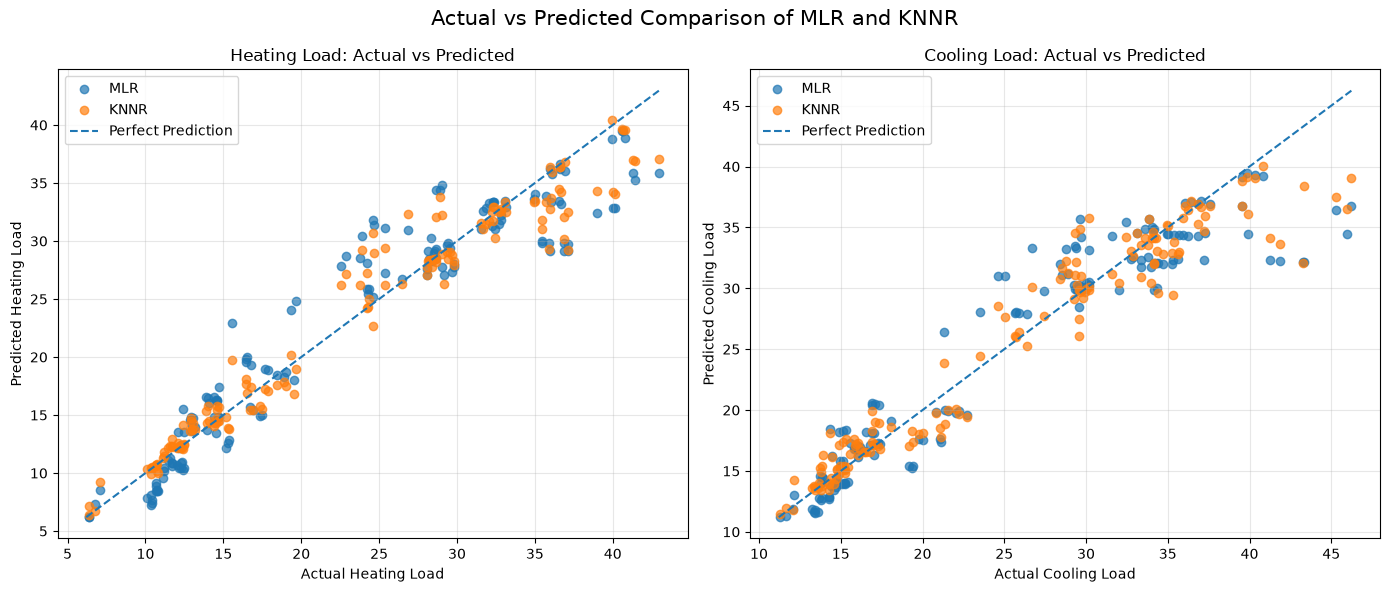

Image saved: actual_vs_predicted_comparison.png


In [17]:
# ============================================================
# CELL 11: ACTUAL VS PREDICTED COMPARISON
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)


# ------------------------------------------------------------
# HEATING LOAD
# ------------------------------------------------------------

axes[0].scatter(
    y_heating_test,
    heating_mlr_predictions,
    alpha=0.7,
    label="MLR"
)

axes[0].scatter(
    y_heating_test,
    heating_knnr_predictions,
    alpha=0.7,
    label="KNNR"
)

heating_min = min(
    y_heating_test.min(),
    heating_mlr_predictions.min(),
    heating_knnr_predictions.min()
)

heating_max = max(
    y_heating_test.max(),
    heating_mlr_predictions.max(),
    heating_knnr_predictions.max()
)

axes[0].plot(
    [heating_min, heating_max],
    [heating_min, heating_max],
    linestyle="--",
    label="Perfect Prediction"
)

axes[0].set_xlabel("Actual Heating Load")
axes[0].set_ylabel("Predicted Heating Load")
axes[0].set_title("Heating Load: Actual vs Predicted")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# COOLING LOAD
# ------------------------------------------------------------

axes[1].scatter(
    y_cooling_test,
    cooling_mlr_predictions,
    alpha=0.7,
    label="MLR"
)

axes[1].scatter(
    y_cooling_test,
    cooling_knnr_predictions,
    alpha=0.7,
    label="KNNR"
)

cooling_min = min(
    y_cooling_test.min(),
    cooling_mlr_predictions.min(),
    cooling_knnr_predictions.min()
)

cooling_max = max(
    y_cooling_test.max(),
    cooling_mlr_predictions.max(),
    cooling_knnr_predictions.max()
)

axes[1].plot(
    [cooling_min, cooling_max],
    [cooling_min, cooling_max],
    linestyle="--",
    label="Perfect Prediction"
)

axes[1].set_xlabel("Actual Cooling Load")
axes[1].set_ylabel("Predicted Cooling Load")
axes[1].set_title("Cooling Load: Actual vs Predicted")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.suptitle(
    "Actual vs Predicted Comparison of MLR and KNNR",
    fontsize=15
)

plt.tight_layout()

# SAVE IMAGE
plt.savefig(
    "actual_vs_predicted_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image saved: actual_vs_predicted_comparison.png")

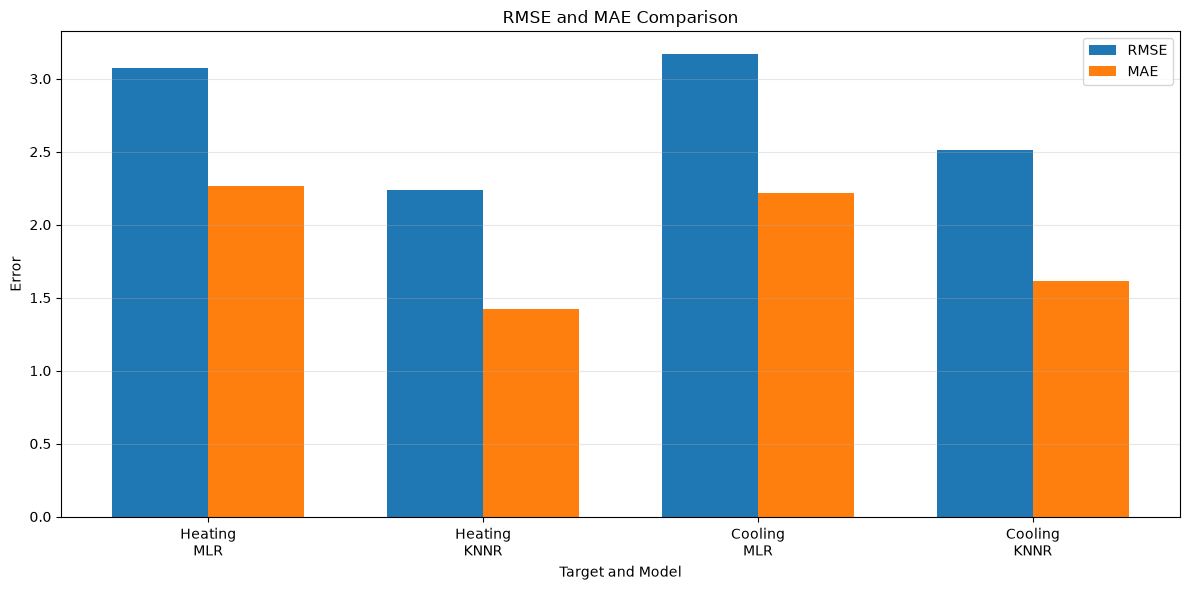

Image saved: error_comparison.png


In [18]:
# ============================================================
# CELL 12: ERROR COMPARISON
# ============================================================

labels = [
    "Heating\nMLR",
    "Heating\nKNNR",
    "Cooling\nMLR",
    "Cooling\nKNNR"
]

rmse_values = [
    heating_mlr_rmse,
    heating_knnr_rmse,
    cooling_mlr_rmse,
    cooling_knnr_rmse
]

mae_values = [
    heating_mlr_mae,
    heating_knnr_mae,
    cooling_mlr_mae,
    cooling_knnr_mae
]

x = np.arange(len(labels))

width = 0.35


plt.figure(figsize=(12, 6))


plt.bar(
    x - width / 2,
    rmse_values,
    width,
    label="RMSE"
)

plt.bar(
    x + width / 2,
    mae_values,
    width,
    label="MAE"
)


plt.xticks(
    x,
    labels
)

plt.xlabel("Target and Model")
plt.ylabel("Error")

plt.title(
    "RMSE and MAE Comparison"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()


# SAVE IMAGE
plt.savefig(
    "error_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image saved: error_comparison.png")

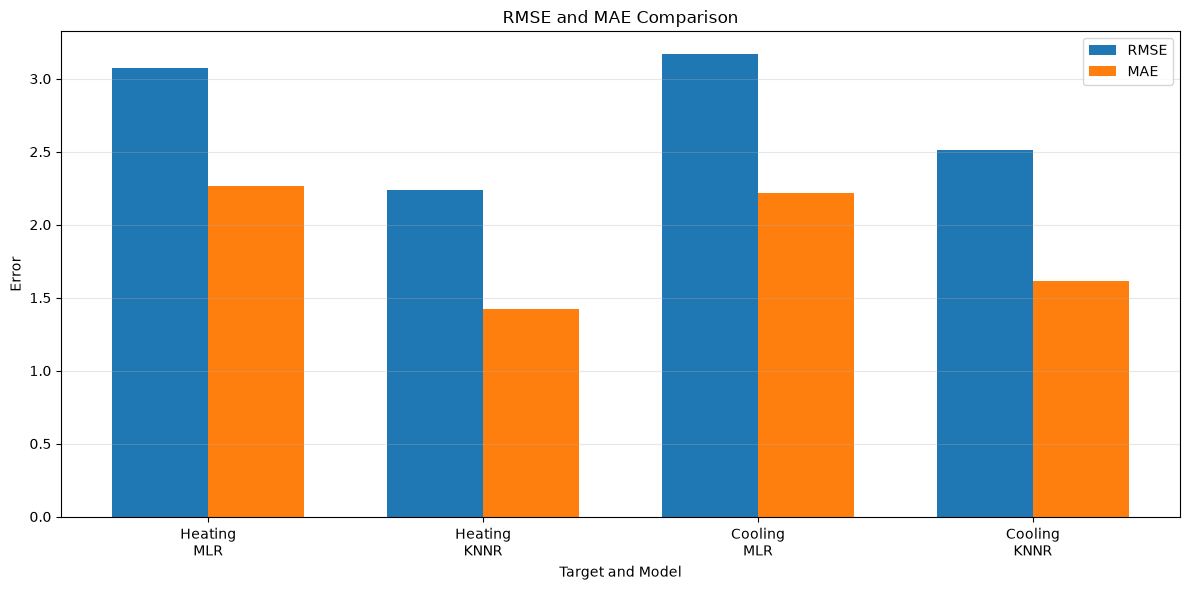

Image saved: error_comparison.png


In [19]:
# ============================================================
# CELL 12: ERROR COMPARISON
# ============================================================

labels = [
    "Heating\nMLR",
    "Heating\nKNNR",
    "Cooling\nMLR",
    "Cooling\nKNNR"
]

rmse_values = [
    heating_mlr_rmse,
    heating_knnr_rmse,
    cooling_mlr_rmse,
    cooling_knnr_rmse
]

mae_values = [
    heating_mlr_mae,
    heating_knnr_mae,
    cooling_mlr_mae,
    cooling_knnr_mae
]

x = np.arange(len(labels))

width = 0.35


plt.figure(figsize=(12, 6))


plt.bar(
    x - width / 2,
    rmse_values,
    width,
    label="RMSE"
)

plt.bar(
    x + width / 2,
    mae_values,
    width,
    label="MAE"
)


plt.xticks(
    x,
    labels
)

plt.xlabel("Target and Model")
plt.ylabel("Error")

plt.title(
    "RMSE and MAE Comparison"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()


# SAVE IMAGE
plt.savefig(
    "error_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image saved: error_comparison.png")

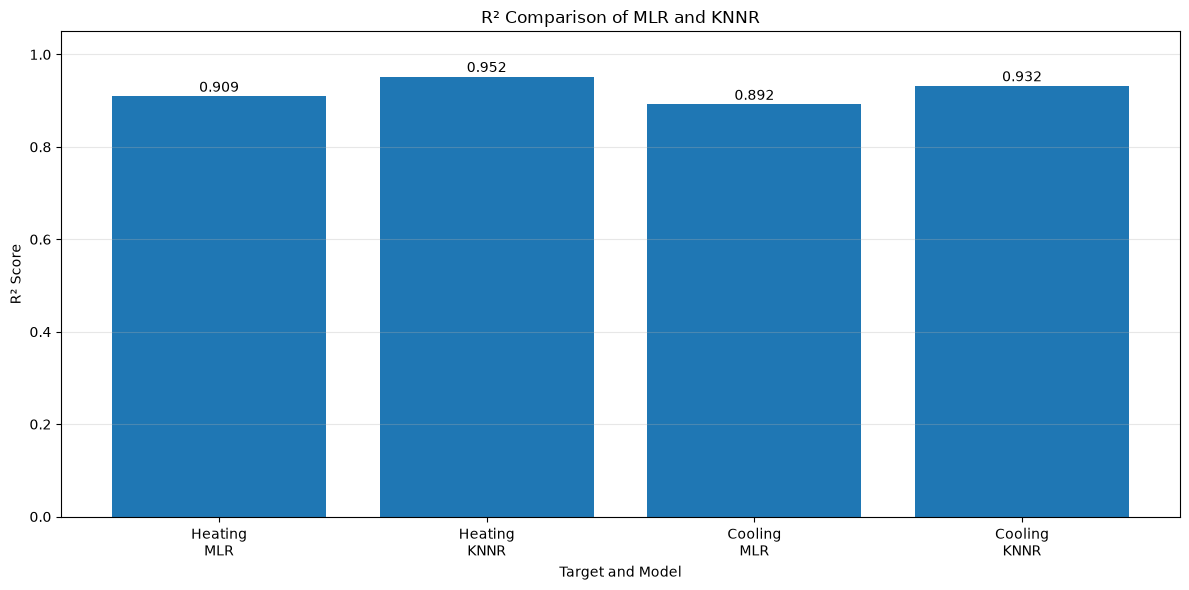

Image saved: r2_comparison.png


In [20]:
# ============================================================
# CELL 13: R² COMPARISON
# ============================================================

labels = [
    "Heating\nMLR",
    "Heating\nKNNR",
    "Cooling\nMLR",
    "Cooling\nKNNR"
]

r2_values = [
    heating_mlr_r2,
    heating_knnr_r2,
    cooling_mlr_r2,
    cooling_knnr_r2
]


plt.figure(figsize=(12, 6))

bars = plt.bar(
    labels,
    r2_values
)

plt.xlabel("Target and Model")
plt.ylabel("R² Score")

plt.title(
    "R² Comparison of MLR and KNNR"
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    axis="y",
    alpha=0.3
)


# Display values above bars
for bar, value in zip(bars, r2_values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )


plt.tight_layout()


# SAVE IMAGE
plt.savefig(
    "r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image saved: r2_comparison.png")

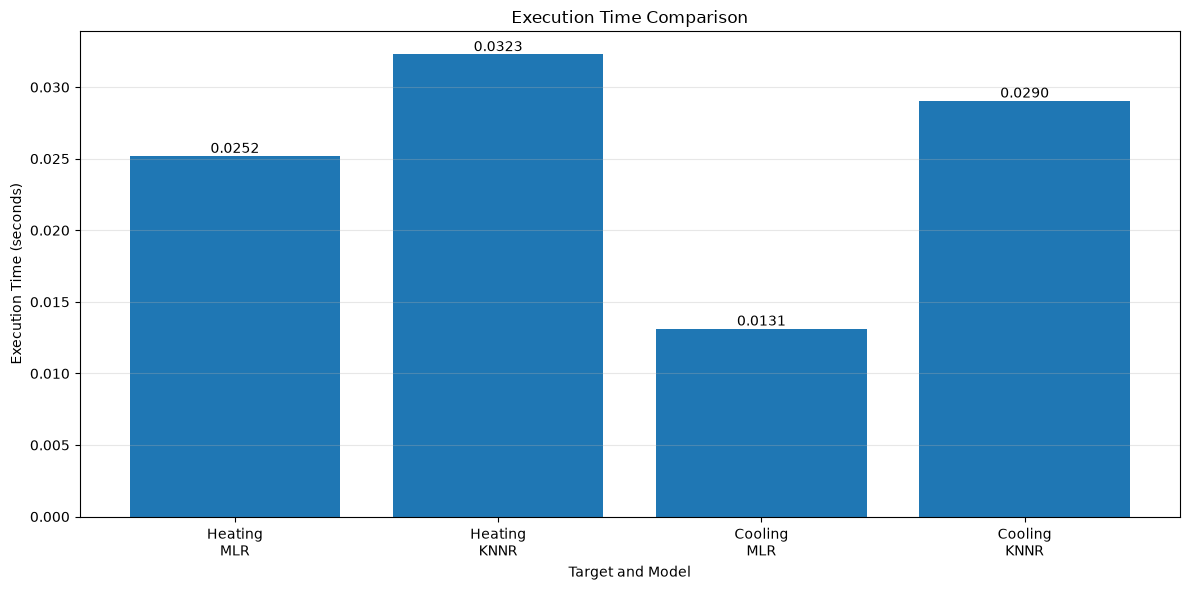

Image saved: time_comparison.png


In [21]:
# ============================================================
# CELL 14: EXECUTION TIME COMPARISON
# ============================================================

labels = [
    "Heating\nMLR",
    "Heating\nKNNR",
    "Cooling\nMLR",
    "Cooling\nKNNR"
]

time_values = [
    heating_mlr_time,
    heating_knnr_time,
    cooling_mlr_time,
    cooling_knnr_time
]


plt.figure(figsize=(12, 6))

bars = plt.bar(
    labels,
    time_values
)

plt.xlabel("Target and Model")
plt.ylabel("Execution Time (seconds)")

plt.title(
    "Execution Time Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)


# Display values above bars
for bar, value in zip(bars, time_values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()


# SAVE IMAGE
plt.savefig(
    "time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image saved: time_comparison.png")

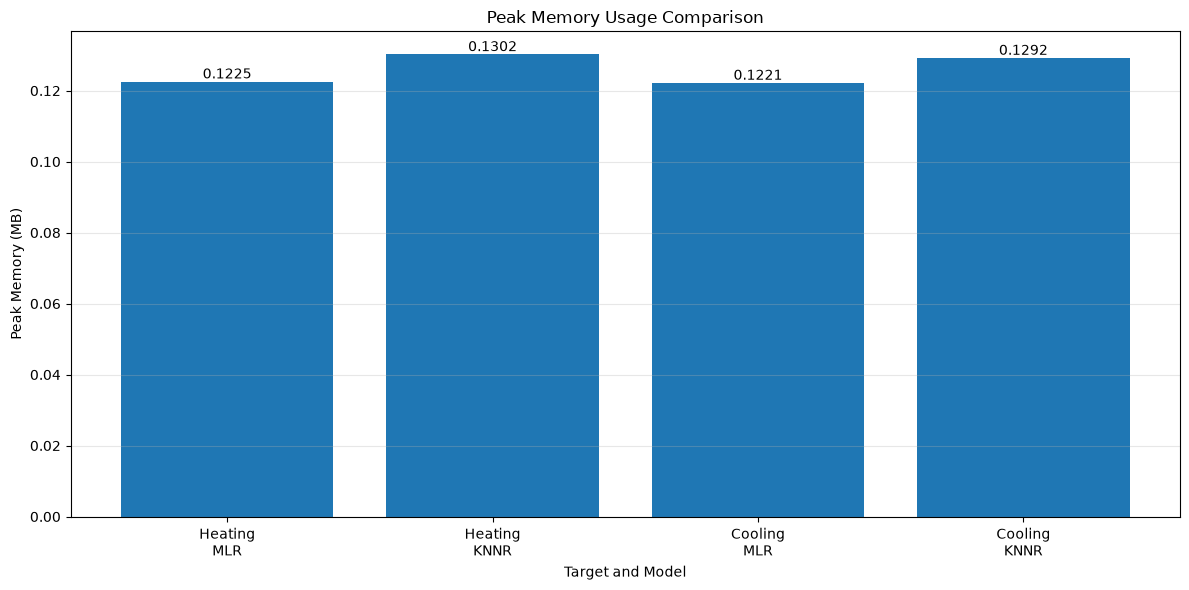

Image saved: memory_comparison.png


In [22]:
# ============================================================
# CELL 15: MEMORY USAGE COMPARISON
# ============================================================

labels = [
    "Heating\nMLR",
    "Heating\nKNNR",
    "Cooling\nMLR",
    "Cooling\nKNNR"
]

memory_values = [
    heating_mlr_memory,
    heating_knnr_memory,
    cooling_mlr_memory,
    cooling_knnr_memory
]


plt.figure(figsize=(12, 6))

bars = plt.bar(
    labels,
    memory_values
)

plt.xlabel("Target and Model")
plt.ylabel("Peak Memory (MB)")

plt.title(
    "Peak Memory Usage Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)


# Display values above bars
for bar, value in zip(bars, memory_values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()


# SAVE IMAGE
plt.savefig(
    "memory_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image saved: memory_comparison.png")

In [23]:
# ============================================================
# CELL 16: CHECK ALL OUTPUT FILES
# ============================================================

output_files = [
    "actual_vs_predicted_comparison.png",
    "error_comparison.png",
    "memory_comparison.png",
    "r2_comparison.png",
    "time_comparison.png",
    "model_performance_results.csv"
]


print("=" * 70)
print("OUTPUT FILE CHECK")
print("=" * 70)

for file_name in output_files:

    if os.path.exists(file_name):

        file_size = os.path.getsize(file_name) / 1024

        print(
            f"✓ {file_name} "
            f"({file_size:.2f} KB)"
        )

    else:

        print(
            f"✗ {file_name} NOT FOUND"
        )

print()
print("All required output files have been generated.")

OUTPUT FILE CHECK
✓ actual_vs_predicted_comparison.png (657.00 KB)
✓ error_comparison.png (89.53 KB)
✓ memory_comparison.png (106.79 KB)
✓ r2_comparison.png (99.60 KB)
✓ time_comparison.png (106.87 KB)
✗ model_performance_results.csv NOT FOUND

All required output files have been generated.


In [25]:
# ============================================================
# SAVE AND VERIFY COMPARISON RESULTS CSV
# ============================================================

comparison_results = pd.DataFrame(results_list)

comparison_results = comparison_results.round(6)

comparison_results.to_csv(
    "comparison_results.csv",
    index=False
)

print("✓ comparison_results.csv saved successfully.")
print()

print("Contents of comparison_results.csv:")
display(comparison_results)

print()
print("File exists:", os.path.exists("comparison_results.csv"))

✓ comparison_results.csv saved successfully.

Contents of comparison_results.csv:


,0,1,2,3,4,5,6
0,Heating Load,MLR,0.909259,3.075400,2.263105,0.025177,0.122502
1,Heating Load,KNNR,0.952007,2.236610,1.424905,0.032283,0.130198
2,Cooling Load,MLR,0.891785,3.166530,2.214961,0.013114,0.122142
3,Cooling Load,KNNR,0.931964,2.510779,1.615893,0.029039,0.129161



File exists: True


In [2]:
readme_content = """
# Assignment 2 - Building Energy Efficiency

## Objective

This project compares Multiple Linear Regression (MLR) and
K-Nearest Neighbors Regression (KNNR) for predicting building
Heating Load and Cooling Load.

## Dataset

The dataset contains 768 observations and 8 input features.

### Input Features

- Relative Compactness
- Surface Area
- Wall Area
- Roof Area
- Overall Height
- Orientation
- Glazing Area
- Glazing Area Distribution

### Target Variables

- Heating Load
- Cooling Load

## Models

1. Multiple Linear Regression (MLR)
2. K-Nearest Neighbors Regression (KNNR)

## Data Split

The dataset was divided into:
- 80% training data
- 20% testing data
- random_state = 42

## KNNR Settings

- K = 5
- Weight = distance
- StandardScaler used for feature scaling

## Evaluation Metrics

- R² Score
- RMSE
- MAE
- Execution Time
- Peak Memory Usage

## Output Files

- comparison_results.csv
- actual_vs_predicted_values.csv
- actual_vs_predicted_comparison.png
- error_comparison.png
- r2_comparison.png
- time_comparison.png
- memory_comparison.png

## Dataset Source

Kaggle dataset URL:
PASTE-YOUR-KAGGLE-URL-HERE

## GitHub

GitHub ID:
PASTE-YOUR-GITHUB-ID-HERE
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md saved successfully.")

README.md saved successfully.
